# SEED-IV hierarchical channel-band attention monitor (diagnostic only)

This notebook keeps the data, LOSO fold, source-only statistics, and monitoring pipeline from `seediv_feature_tuning_monitor.ipynb`, but replaces the flat feature projection with a hierarchy that explicitly models **band → channel → time** relationships.

The cached window remains unchanged. A flat `[B, T, 62×F]` batch is reshaped inside the model to `[B, T, 62, F]`, so this experiment is directly comparable with the plain Transformer without regenerating data.

> **Target-peeking warning:** the held-out target subject is evaluated and inspected every few epochs for diagnosis. Do not select a reportable epoch or hyperparameters from these target curves/attention maps. Use source validation or a pre-fixed configuration for formal results.


In [1]:
from __future__ import annotations

import gc
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn
from torch.utils.data import DataLoader


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'src' / 'cmrd').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the CMRD repository')


ROOT = find_project_root(Path.cwd())
for path in (ROOT / 'src', ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import train_seediv_de_rjsd_ica as feature_pipeline
from cmrd.data.records import TrialSample
from cmrd.features.rd import normalize_histograms, transform_rd
from cmrd.models import HierarchicalChannelBandTransformer
from cmrd.training.engine import SequenceDataset, collate_sequences, fit_normalizer
from cmrd.training.metrics import classification_metrics
from cmrd.training.runtime import seed_everything

print('Project:', ROOT)
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Project: C:\Users\Lin\Documents\Arbitruam\CMRD-Cute-Mew-Really-Delighting
PyTorch: 2.13.0.dev20260422+cu132
CUDA available: True
GPU: NVIDIA GeForce RTX 5080 Laptop GPU


## Parameters

Start with one target subject. `RJSD`, `CMRD`, and `DE` each give five physiological band slots per channel. `FUSION` is also supported and gives 15 channel-local slots in the order `RJSD(5), CMRD(5), zDE(5)`.

`BATCH_SIZE=8` and `d_model=64` are conservative defaults because channel attention is applied once per valid time window. Increase them only after checking GPU memory.


In [2]:
# Data / feature
FEATURE = 'RJSD'              # CMRD | RJSD | DE | FUSION (case-insensitive)
ALPHA = 0.5                   # Used by CMRD/FUSION only
DATA_ROOT = None              # None = auto-discover the completed signature cache
TARGET_SUBJECTS = [1]         # For all folds: list(range(1, 16))
NUM_CHANNELS = 62

# Training
EPOCHS = 80
TEST_EVERY = 10               # Evaluate source/target every N epochs
BATCH_SIZE = 8                # Channel attention is more memory-intensive than the flat baseline
LEARNING_RATE = 1e-4
MINIMUM_LEARNING_RATE = 1e-6
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
GRADIENT_CLIP_NORM = 1.0
SEED = 42
DETERMINISTIC = True
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = 0               # Safest setting for Windows/Jupyter

# Hierarchical model: band attention -> channel MHA/pooling -> temporal Transformer.
MODEL_NAME = 'hierarchical_channel_band_transformer'
MODEL_CONFIG = {
    'd_model': 64,
    'channel_heads': 4,
    'temporal_heads': 4,
    'temporal_layers': 3,
    'feedforward': 256,
    'dropout': 0.2,
}

# Output / interpretability
RUN_TAG = f"{FEATURE.lower()}_{MODEL_NAME}_all_source_every{TEST_EVERY}_diagnostic"
RESUME_COMPLETED_FOLDS = True
SAVE_FINAL_CHECKPOINT = True
SAVE_TARGET_ATTENTION = True
ATTENTION_MAX_BATCHES = None   # None = all 72 target trials; integer = faster approximation

FEATURE = feature_pipeline._feature_name(FEATURE)
assert FEATURE in feature_pipeline.FEATURES
assert all(1 <= subject <= 15 for subject in TARGET_SUBJECTS)
assert len(TARGET_SUBJECTS) == len(set(TARGET_SUBJECTS))
assert MODEL_CONFIG['d_model'] % MODEL_CONFIG['channel_heads'] == 0
assert MODEL_CONFIG['d_model'] % MODEL_CONFIG['temporal_heads'] == 0
assert EPOCHS > 0 and BATCH_SIZE > 0 and TEST_EVERY > 0 and NUM_CHANNELS > 0
DEVICE_OBJ = torch.device(DEVICE)
RUN_DIR = ROOT / 'runs' / 'diagnostics' / 'seediv_hierarchical_attention' / RUN_TAG
RUN_DIR.mkdir(parents=True, exist_ok=True)

print('Feature:', FEATURE.upper())
print('Targets:', TARGET_SUBJECTS)
print('Device:', DEVICE_OBJ)
print('Output:', RUN_DIR)


Feature: DE
Targets: [1]
Device: cuda
Output: C:\Users\Lin\Documents\Arbitruam\CMRD-Cute-Mew-Really-Delighting\runs\diagnostics\seediv_hierarchical_attention\de_hierarchical_channel_band_transformer_all_source_every10_diagnostic


## Hierarchical attention model

For every valid time window the model performs:

1. **Band attention:** scalar feature values receive learned band/slot and channel identities; a learned softmax pools slots within each channel.
2. **Channel relation:** multi-head self-attention relates all 62 channel tokens, then a second learned softmax pools channels.
3. **Temporal relation:** a masked Transformer relates window tokens across the trial.
4. **Trial classification:** masked mean pooling and a nonlinear classifier produce four logits.

The normal training call is still `model(data, mask) -> logits`. Calling `model(data, mask, return_attention=True)` additionally returns band and channel pooling weights for inspection.


In [3]:
def build_model(input_dim: int, classes: int, max_length: int) -> nn.Module:
    if input_dim % NUM_CHANNELS != 0:
        raise ValueError(f'input_dim={input_dim} is not divisible by {NUM_CHANNELS} channels')
    print(
        f'Model input: [B,T,{NUM_CHANNELS},{input_dim // NUM_CHANNELS}] '
        f'(flattened loader dimension={input_dim})'
    )
    return HierarchicalChannelBandTransformer(
        input_dim=input_dim,
        channels=NUM_CHANNELS,
        classes=classes,
        max_length=max_length,
        **MODEL_CONFIG,
    )


## Data and metric helpers

Each fold uses all 14 non-target subjects (1008 trials) for training and the held-out target subject (72 trials) for testing. RJSD reference, zDE statistics, and normalization are fitted from those 14 source subjects only. Samples stay flat in the loader and are reshaped to channel/slot axes only inside the model.


In [4]:
DATA_ROOT_PATH = feature_pipeline._resolve_data_root(DATA_ROOT)
CACHE_AUDIT = feature_pipeline.validate_cache(DATA_ROOT_PATH, deep=False)
print('Data root:', DATA_ROOT_PATH)
print('Cache:', CACHE_AUDIT['trials'], 'trials,', CACHE_AUDIT['folds'], 'folds')
print('ICA audit:', CACHE_AUDIT['ica'])
environment_path = DATA_ROOT_PATH / 'environment.json'
environment = json.loads(environment_path.read_text(encoding='utf-8')) if environment_path.is_file() else {}
CHANNEL_NAMES = list(environment.get('signature_payload', {}).get('channel_names', []))
if len(CHANNEL_NAMES) != NUM_CHANNELS:
    CHANNEL_NAMES = [f'channel_{index + 1:02d}' for index in range(NUM_CHANNELS)]
BAND_NAMES = ['delta', 'theta', 'alpha', 'beta', 'gamma']
print('Channel labels:', CHANNEL_NAMES[:5], '...', CHANNEL_NAMES[-3:])
ALL_SOURCE_STATS_ROOT = ROOT / 'runs' / 'diagnostics' / 'seediv_feature_tuning' / '_all_source_statistics'
_PREPARED_FOLD_CACHE = {}  # Keeps only the most recently prepared fold in memory


def make_loader(samples, mean, std, shuffle: bool, seed: int) -> DataLoader:
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        SequenceDataset(samples, mean, std),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE_OBJ.type == 'cuda',
        collate_fn=collate_sequences,
        generator=generator,
    )


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> dict:
    model.eval()
    targets, predictions = [], []
    loss_sum = 0.0
    count = 0
    for data, mask, labels in loader:
        data = data.to(DEVICE_OBJ, non_blocking=True)
        mask = mask.to(DEVICE_OBJ, non_blocking=True)
        labels_device = labels.to(DEVICE_OBJ, non_blocking=True)
        logits = model(data, mask)
        loss = criterion(logits, labels_device)
        loss_sum += float(loss.item()) * labels.shape[0]
        count += labels.shape[0]
        targets.append(labels.numpy())
        predictions.append(logits.argmax(dim=1).cpu().numpy())
    metrics = classification_metrics(np.concatenate(targets), np.concatenate(predictions), classes=4)
    metrics['loss'] = loss_sum / count
    return metrics


def print_domain_metrics(name: str, metrics: dict) -> None:
    print(
        f"  {name}: loss={metrics['loss']:.4f} ACC={metrics['accuracy']:.4f} "
        f"BACC={metrics['balanced_accuracy']:.4f} Macro-F1={metrics['macro_f1']:.4f}"
    )
    for row in metrics['per_class']:
        print(
            f"    class={row['class']} P={row['precision']:.4f} R={row['recall']:.4f} "
            f"F1={row['f1']:.4f} support={row['support']}"
        )
    print(f"    confusion_matrix={metrics['confusion_matrix']}")


def fit_all_source_statistics(entries, need_de: bool, need_reference: bool):
    de_total = np.zeros((62, 5), dtype=np.float64) if need_de else None
    de_total_sq = np.zeros((62, 5), dtype=np.float64) if need_de else None
    reference_total = np.zeros((62, 5, 32), dtype=np.float64) if need_reference else None
    window_count = 0
    for entry in entries:
        with np.load(DATA_ROOT_PATH / entry['de_phist_path'], allow_pickle=False) as archive:
            if need_de:
                de = np.asarray(archive['de'], dtype=np.float64)
                de_total += de.sum(axis=0)
                de_total_sq += np.square(de).sum(axis=0)
            if need_reference:
                histogram = normalize_histograms(np.asarray(archive['p_hist'], dtype=np.float32))
                reference_total += histogram.sum(axis=0, dtype=np.float64)
            window_count += int(archive['de'].shape[0])
    de_mean = de_std = reference = None
    if need_de:
        de_mean = de_total / window_count
        variance = np.maximum(de_total_sq / window_count - np.square(de_mean), 0.0)
        de_std = np.sqrt(variance)
        de_std[de_std < 1e-6] = 1.0
        de_mean, de_std = de_mean.astype(np.float32), de_std.astype(np.float32)
    if need_reference:
        reference = normalize_histograms(reference_total / window_count)
    return de_mean, de_std, reference, window_count


def load_samples(entries, de_mean, de_std, reference):
    samples = []
    for entry in entries:
        need_de = FEATURE in {'de', 'cmrd', 'fusion'}
        need_rjsd = FEATURE in {'rjsd', 'cmrd', 'fusion'}
        de = rjsd = None
        with np.load(DATA_ROOT_PATH / entry['de_phist_path'], allow_pickle=False) as archive:
            if need_de:
                de = np.asarray(archive['de'], dtype=np.float32)
            if need_rjsd:
                histogram = np.asarray(archive['p_hist'], dtype=np.float32)
                flat = transform_rd(histogram, reference)
                rjsd = flat.reshape(flat.shape[0], 62, 5)
        if FEATURE == 'de':
            value = de
        elif FEATURE == 'rjsd':
            value = rjsd
        else:
            zde = (de - de_mean[None]) / de_std[None]
            cmrd = np.tanh(ALPHA * zde) * rjsd
            value = cmrd if FEATURE == 'cmrd' else np.concatenate((rjsd, cmrd, zde), axis=-1)
        samples.append(TrialSample(
            np.ascontiguousarray(value.reshape(value.shape[0], -1), dtype=np.float32),
            int(entry['label']), int(entry['subject']), int(entry['session']),
            int(entry['trial']), int(entry['source_index']),
        ))
    return samples


def prepare_fold(target_subject: int):
    cache_key = (int(target_subject), FEATURE, float(ALPHA), CACHE_AUDIT['preprocessing_signature'])
    if cache_key in _PREPARED_FOLD_CACHE:
        print(f'Reusing prepared fold {target_subject:02d} from memory')
        return _PREPARED_FOLD_CACHE[cache_key]
    fold_root = DATA_ROOT_PATH / 'folds' / f'fold-{target_subject:02d}'
    manifest = json.loads((fold_root / 'manifest.json').read_text(encoding='utf-8'))
    groups = manifest['groups']
    source_entries = sorted(groups['train'] + groups['validation'], key=lambda entry: int(entry['source_index']))
    target_entries = list(groups['test'])
    source_subjects = sorted({int(entry['subject']) for entry in source_entries})
    assert len(source_entries) == 1008 and len(source_subjects) == 14
    assert len(target_entries) == 72 and {int(entry['subject']) for entry in target_entries} == {target_subject}
    assert target_subject not in source_subjects

    need_de_stats = FEATURE in {'cmrd', 'fusion'}
    need_reference = FEATURE in {'rjsd', 'cmrd', 'fusion'}
    if need_de_stats or need_reference:
        stats_dir = ALL_SOURCE_STATS_ROOT / CACHE_AUDIT['preprocessing_signature']
        stats_dir.mkdir(parents=True, exist_ok=True)
        stats_path = stats_dir / f'fold-{target_subject:02d}.npz'
        if stats_path.is_file():
            with np.load(stats_path, allow_pickle=False) as archive:
                de_mean = np.asarray(archive['de_mean'], dtype=np.float32)
                de_std = np.asarray(archive['de_std'], dtype=np.float32)
                reference = np.asarray(archive['rjsd_reference'], dtype=np.float32)
                source_window_count = int(archive['source_window_count'])
                cached_subjects = list(map(int, archive['source_subjects']))
            if cached_subjects != source_subjects:
                raise RuntimeError(f'All-source statistics cache has wrong subjects: {stats_path}')
            print('Reusing all-source DE/RJSD statistics:', stats_path)
        else:
            print('Fitting all-source DE/RJSD statistics (first run for this fold) ...')
            de_mean, de_std, reference, source_window_count = fit_all_source_statistics(
                source_entries, need_de=True, need_reference=True
            )
            np.savez_compressed(
                stats_path, de_mean=de_mean, de_std=de_std, rjsd_reference=reference,
                source_window_count=np.int64(source_window_count), source_subjects=np.asarray(source_subjects),
            )
        if not need_de_stats:
            de_mean = de_std = None
        if not need_reference:
            reference = None
    else:
        de_mean = de_std = reference = None
        source_window_count = 0
    train_samples = load_samples(source_entries, de_mean, de_std, reference)
    target_samples = load_samples(target_entries, de_mean, de_std, reference)
    split = {'train_subjects': source_subjects, 'target_subject': target_subject, 'protocol': '14-source-train/1-target-test'}
    prepared = (train_samples, target_samples, split, de_mean, de_std, reference, source_window_count)
    _PREPARED_FOLD_CACHE.clear()
    _PREPARED_FOLD_CACHE[cache_key] = prepared
    return prepared


def feature_slot_names(count: int) -> list[str]:
    if count == len(BAND_NAMES):
        return BAND_NAMES
    if count == 3 * len(BAND_NAMES):
        return [f'{family}_{band}' for family in ('rjsd', 'cmrd', 'zde') for band in BAND_NAMES]
    return [f'slot_{index + 1:02d}' for index in range(count)]


@torch.no_grad()
def save_attention_summary(
    model: HierarchicalChannelBandTransformer,
    loader: DataLoader,
    output_dir: Path,
    prefix: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    model.eval()
    band_total = None
    channel_total = None
    valid_windows = 0
    for batch_index, (data, mask, _) in enumerate(loader):
        if ATTENTION_MAX_BATCHES is not None and batch_index >= ATTENTION_MAX_BATCHES:
            break
        data = data.to(DEVICE_OBJ, non_blocking=True)
        mask = mask.to(DEVICE_OBJ, non_blocking=True)
        _, attention = model(data, mask, return_attention=True)
        current_band = attention['band'].sum(dim=(0, 1)).double().cpu()
        current_channel = attention['channel'].sum(dim=(0, 1)).double().cpu()
        band_total = current_band if band_total is None else band_total + current_band
        channel_total = current_channel if channel_total is None else channel_total + current_channel
        valid_windows += int(mask.sum().item())
    if valid_windows == 0 or band_total is None or channel_total is None:
        raise RuntimeError('Attention summary received no valid windows')

    band_mean = (band_total / valid_windows).numpy()
    channel_mean = (channel_total / valid_windows).numpy()
    slots = feature_slot_names(band_mean.shape[1])
    channel_frame = pd.DataFrame({
        'channel_index': np.arange(1, NUM_CHANNELS + 1),
        'channel': CHANNEL_NAMES,
        'mean_attention': channel_mean,
    }).sort_values('mean_attention', ascending=False, ignore_index=True)
    band_frame = pd.DataFrame([
        {
            'channel_index': channel_index + 1,
            'channel': CHANNEL_NAMES[channel_index],
            'slot_index': slot_index + 1,
            'slot': slots[slot_index],
            'mean_attention': float(band_mean[channel_index, slot_index]),
        }
        for channel_index in range(NUM_CHANNELS)
        for slot_index in range(len(slots))
    ])
    channel_frame.to_csv(output_dir / f'{prefix}_channel_attention.csv', index=False)
    band_frame.to_csv(output_dir / f'{prefix}_band_attention.csv', index=False)
    return channel_frame, band_frame


Data root: C:\Users\Lin\Documents\Arbitruam\Dataset\Processed\CMRD\seediv\de_rjsd_ica_1s_hop05\946b467993249ad9
Cache: 1080 trials, 15 folds
ICA audit: {'metadata_files': 1080, 'primary_fit_fallbacks': 8, 'detection_errors': 0, 'trials_with_zero_exclusions': 1, 'trials_with_cleaned_std_over_100_microvolt': 15}
Channel labels: ['Fp1', 'Fpz', 'Fp2', 'AF3', 'AF4'] ... ['Oz', 'O2', 'CB2']


## Per-epoch training loop

Training loss is printed every epoch. Every `TEST_EVERY` epochs, the notebook evaluates the complete source domain and held-out target subject. At the final epoch it also aggregates target band/channel attention into CSV files. These weights describe the model's learned pooling distributions—not causal importance—and remain target-peeked diagnostic outputs.


In [5]:
SETTINGS = {
    'feature': FEATURE,
    'alpha': ALPHA,
    'targets': TARGET_SUBJECTS,
    'epochs': EPOCHS,
    'test_every': TEST_EVERY,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'minimum_learning_rate': MINIMUM_LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'label_smoothing': LABEL_SMOOTHING,
    'gradient_clip_norm': GRADIENT_CLIP_NORM,
    'split_protocol': '14-source-train/1-target-test',
    'seed': SEED,
    'deterministic': DETERMINISTIC,
    'device': DEVICE,
    'model_name': MODEL_NAME,
    'model_config': MODEL_CONFIG,
    'num_channels': NUM_CHANNELS,
    'save_target_attention': SAVE_TARGET_ATTENTION,
    'attention_max_batches': ATTENTION_MAX_BATCHES,
    'preprocessing_signature': CACHE_AUDIT['preprocessing_signature'],
    'diagnostic_target_peeking': True,
}
settings_path = RUN_DIR / 'settings.json'
if settings_path.is_file():
    previous = json.loads(settings_path.read_text(encoding='utf-8'))
    if previous != SETTINGS:
        raise RuntimeError('RUN_TAG already exists with different settings; change RUN_TAG')
else:
    settings_path.write_text(json.dumps(SETTINGS, indent=2, ensure_ascii=False), encoding='utf-8')


def train_one_fold(target_subject: int) -> pd.DataFrame:
    fold_dir = RUN_DIR / f'fold-{target_subject:02d}'
    fold_dir.mkdir(parents=True, exist_ok=True)
    epoch_csv = fold_dir / 'epochs.csv'
    evaluation_csv = fold_dir / 'evaluations.csv'
    attention_files = (
        fold_dir / 'target_channel_attention.csv',
        fold_dir / 'target_band_attention.csv',
    )
    attention_ready = not SAVE_TARGET_ATTENTION or all(path.is_file() for path in attention_files)
    if RESUME_COMPLETED_FOLDS and epoch_csv.is_file() and evaluation_csv.is_file() and attention_ready:
        previous_epochs = pd.read_csv(epoch_csv)
        previous_evaluations = pd.read_csv(evaluation_csv)
        if len(previous_epochs) == EPOCHS and int(previous_epochs['epoch'].max()) == EPOCHS:
            print(f'fold={target_subject:02d}: reused {EPOCHS} completed epochs')
            return previous_evaluations

    seed_everything(SEED, DETERMINISTIC)
    train_samples, target_samples, split, de_mean, de_std, reference, source_window_count = prepare_fold(target_subject)
    normalizer_mean, normalizer_std = fit_normalizer(train_samples)
    train_loader = make_loader(train_samples, normalizer_mean, normalizer_std, True, SEED)
    source_eval_loader = make_loader(train_samples, normalizer_mean, normalizer_std, False, SEED)
    target_loader = make_loader(target_samples, normalizer_mean, normalizer_std, False, SEED)

    all_samples = train_samples + target_samples
    input_dim = train_samples[0].x.shape[1]
    max_length = max(sample.x.shape[0] for sample in all_samples)
    model = build_model(input_dim=input_dim, classes=4, max_length=max_length).to(DEVICE_OBJ)
    parameter_count = sum(parameter.numel() for parameter in model.parameters())
    print(f'Model parameters: {parameter_count:,}')
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=MINIMUM_LEARNING_RATE
    )

    epoch_rows = []
    evaluation_rows = []
    started = time.perf_counter()
    print(
        f'fold={target_subject:02d} feature={FEATURE.upper()} '
        f'train/test trials={len(train_samples)}/{len(target_samples)} '
        f'input_dim={input_dim} windows<= {max_length}'
    )

    for epoch in range(1, EPOCHS + 1):
        model.train()
        loss_sum = 0.0
        seen = 0
        for data, mask, labels in train_loader:
            data = data.to(DEVICE_OBJ, non_blocking=True)
            mask = mask.to(DEVICE_OBJ, non_blocking=True)
            labels = labels.to(DEVICE_OBJ, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(data, mask)
            loss = criterion(logits, labels)
            loss.backward()
            if GRADIENT_CLIP_NORM > 0:
                nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
            optimizer.step()
            loss_sum += float(loss.item()) * labels.shape[0]
            seen += labels.shape[0]
        scheduler.step()

        epoch_row = {
            'epoch': epoch,
            'train_loss': loss_sum / seen,
            'learning_rate': optimizer.param_groups[0]['lr'],
            'elapsed_seconds': time.perf_counter() - started,
        }
        epoch_rows.append(epoch_row)
        pd.DataFrame(epoch_rows).to_csv(epoch_csv, index=False)
        print(f"fold={target_subject:02d} epoch={epoch:03d}/{EPOCHS} train_loss={epoch_row['train_loss']:.4f}")

        if epoch % TEST_EVERY == 0 or epoch == EPOCHS:
            source_metrics = evaluate_model(model, source_eval_loader, criterion)
            target_metrics = evaluate_model(model, target_loader, criterion)
            evaluation_row = {
                'target_subject': target_subject,
                'feature': FEATURE,
                'epoch': epoch,
                'train_loss': epoch_row['train_loss'],
                'source_loss': source_metrics['loss'],
                'source_accuracy': source_metrics['accuracy'],
                'source_balanced_accuracy': source_metrics['balanced_accuracy'],
                'source_macro_f1': source_metrics['macro_f1'],
                'source_per_class': json.dumps(source_metrics['per_class'], separators=(',', ':')),
                'source_confusion_matrix': json.dumps(source_metrics['confusion_matrix'], separators=(',', ':')),
                'target_loss': target_metrics['loss'],
                'target_accuracy': target_metrics['accuracy'],
                'target_balanced_accuracy': target_metrics['balanced_accuracy'],
                'target_macro_f1': target_metrics['macro_f1'],
                'target_per_class': json.dumps(target_metrics['per_class'], separators=(',', ':')),
                'target_confusion_matrix': json.dumps(target_metrics['confusion_matrix'], separators=(',', ':')),
                'elapsed_seconds': epoch_row['elapsed_seconds'],
            }
            evaluation_rows.append(evaluation_row)
            pd.DataFrame(evaluation_rows).to_csv(evaluation_csv, index=False)
            print(f'--- diagnostic evaluation: fold={target_subject:02d} epoch={epoch:03d} ---')
            print_domain_metrics('SOURCE', source_metrics)
            print_domain_metrics('TARGET', target_metrics)

    if SAVE_TARGET_ATTENTION:
        channel_attention, band_attention = save_attention_summary(
            model, target_loader, fold_dir, prefix='target'
        )
        print('Top target channel attention (diagnostic):')
        display(channel_attention.head(10))

    if SAVE_FINAL_CHECKPOINT:
        torch.save(
            {
                'model_state_dict': {key: value.detach().cpu() for key, value in model.state_dict().items()},
                'normalization_mean': normalizer_mean,
                'normalization_std': normalizer_std,
                'de_mean': de_mean,
                'de_std': de_std,
                'rjsd_reference': reference,
                'source_train_windows': source_window_count,
                'final_epoch': int(epoch_rows[-1]['epoch']),
                'split': split,
                'settings': SETTINGS,
                'warning': 'Target was evaluated every TEST_EVERY epochs; diagnostic only.',
            },
            fold_dir / 'final_epoch.pt',
        )

    frame = pd.DataFrame(evaluation_rows)
    del model, optimizer, scheduler, train_loader, source_eval_loader, target_loader
    del train_samples, target_samples, all_samples
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return frame

## Run selected LOSO folds

The table refreshes after every completed fold. `target_*` metrics and attention summaries are deliberately diagnostic and target-peeked.


In [6]:
fold_frames = []
for target_subject in TARGET_SUBJECTS:
    fold_frame = train_one_fold(target_subject)
    fold_frames.append(fold_frame)
    display(fold_frame.tail(1))

all_epochs = pd.concat(fold_frames, ignore_index=True)
all_epochs.to_csv(RUN_DIR / 'all_fold_epochs.csv', index=False)
epoch_summary = (
    all_epochs.groupby('epoch', as_index=False)
    .agg(
        source_accuracy_mean=('source_accuracy', 'mean'),
        source_macro_f1_mean=('source_macro_f1', 'mean'),
        target_accuracy_mean=('target_accuracy', 'mean'),
        target_accuracy_std=('target_accuracy', lambda values: values.std(ddof=0)),
        target_macro_f1_mean=('target_macro_f1', 'mean'),
        target_macro_f1_std=('target_macro_f1', lambda values: values.std(ddof=0)),
        subjects=('target_subject', 'nunique'),
    )
)
epoch_summary.to_csv(RUN_DIR / 'epoch_summary.csv', index=False)
display(epoch_summary.tail(20).style.format({
    'source_accuracy_mean': '{:.2%}',
    'source_macro_f1_mean': '{:.2%}',
    'target_accuracy_mean': '{:.2%}',
    'target_accuracy_std': '{:.2%}',
    'target_macro_f1_mean': '{:.2%}',
    'target_macro_f1_std': '{:.2%}',
}))

Model input: [B,T,62,5] (flattened loader dimension=310)
Model parameters: 221,892
fold=01 feature=DE train/test trials=1008/72 input_dim=310 windows<= 517
fold=01 epoch=001/100 train_loss=1.3929
fold=01 epoch=002/100 train_loss=1.3770
fold=01 epoch=003/100 train_loss=1.3569
fold=01 epoch=004/100 train_loss=1.3358
fold=01 epoch=005/100 train_loss=1.3096
fold=01 epoch=006/100 train_loss=1.2879
fold=01 epoch=007/100 train_loss=1.2666
fold=01 epoch=008/100 train_loss=1.2522
fold=01 epoch=009/100 train_loss=1.2360
fold=01 epoch=010/100 train_loss=1.2122
--- diagnostic evaluation: fold=01 epoch=010 ---
  SOURCE: loss=1.1878 ACC=0.5565 BACC=0.5565 Macro-F1=0.5500
    class=0 P=0.6875 R=0.3929 F1=0.5000 support=252
    class=1 P=0.5064 R=0.7857 F1=0.6159 support=252
    class=2 P=0.4901 R=0.4921 F1=0.4911 support=252
    class=3 P=0.6364 R=0.5556 F1=0.5932 support=252
    confusion_matrix=[[99, 99, 14, 40], [3, 198, 44, 7], [42, 53, 124, 33], [0, 41, 71, 140]]
  TARGET: loss=1.1849 ACC=0.5556

,channel_index,channel,mean_attention
0,54,POz,0.017144
1,46,Pz,0.017050
2,60,Oz,0.016656
3,49,P6,0.016650
4,50,P8,0.016638
5,61,O2,0.016624
6,62,CB2,0.016580
7,57,PO8,0.016526
8,48,P4,0.016523
9,55,PO4,0.016501


,target_subject,feature,epoch,train_loss,source_loss,source_accuracy,source_balanced_accuracy,source_macro_f1,source_per_class,source_confusion_matrix,target_loss,target_accuracy,target_balanced_accuracy,target_macro_f1,target_per_class,target_confusion_matrix,elapsed_seconds
9,1,de,100,0.745287,0.721883,0.90873,0.90873,0.908407,"[{""class"":0,""precision"":0.889344262295082,""rec...","[[217,17,5,13],[4,247,0,1],[22,13,217,0],[1,9,...",0.801487,0.833333,0.833333,0.834418,"[{""class"":0,""precision"":0.7142857142857143,""re...","[[15,2,0,1],[2,15,0,1],[3,2,13,0],[1,0,0,17]]",972.306125


,epoch,source_accuracy_mean,source_macro_f1_mean,target_accuracy_mean,target_accuracy_std,target_macro_f1_mean,target_macro_f1_std,subjects
0,10,55.65%,55.00%,55.56%,0.00%,54.96%,0.00%,1
1,20,64.19%,64.30%,58.33%,0.00%,57.92%,0.00%,1
2,30,69.35%,69.81%,63.89%,0.00%,64.42%,0.00%,1
3,40,79.17%,78.97%,70.83%,0.00%,69.88%,0.00%,1
4,50,84.13%,83.92%,70.83%,0.00%,70.74%,0.00%,1
5,60,86.81%,86.81%,77.78%,0.00%,77.92%,0.00%,1
6,70,88.89%,88.81%,81.94%,0.00%,81.74%,0.00%,1
7,80,91.17%,91.14%,81.94%,0.00%,82.01%,0.00%,1
8,90,90.28%,90.23%,83.33%,0.00%,83.44%,0.00%,1
9,100,90.87%,90.84%,83.33%,0.00%,83.44%,0.00%,1


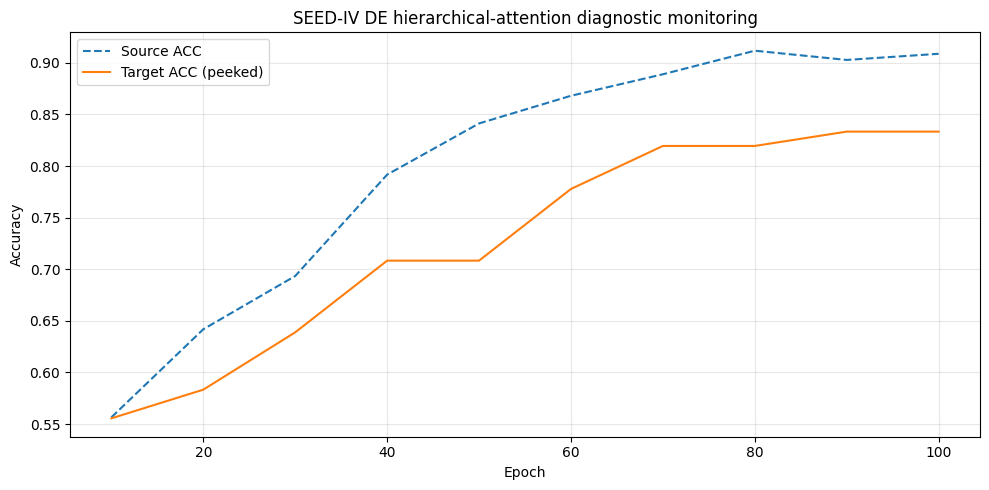

In [7]:
# Optional diagnostic curves.
try:
    import matplotlib.pyplot as plt

    figure, axis = plt.subplots(figsize=(10, 5))
    axis.plot(epoch_summary['epoch'], epoch_summary['source_accuracy_mean'], '--', label='Source ACC')
    axis.plot(epoch_summary['epoch'], epoch_summary['target_accuracy_mean'], label='Target ACC (peeked)')
    axis.fill_between(
        epoch_summary['epoch'],
        epoch_summary['target_accuracy_mean'] - epoch_summary['target_accuracy_std'],
        epoch_summary['target_accuracy_mean'] + epoch_summary['target_accuracy_std'],
        alpha=0.2,
    )
    axis.set(xlabel='Epoch', ylabel='Accuracy', title=f'SEED-IV {FEATURE.upper()} hierarchical-attention diagnostic monitoring')
    axis.grid(alpha=0.3)
    axis.legend()
    figure.tight_layout()
    figure.savefig(RUN_DIR / 'accuracy_curve.png', dpi=160)
    plt.show()
except ModuleNotFoundError:
    print('matplotlib is unavailable; CSV results were still saved')

## Inspect learned pooling attention

This view uses the last selected fold. Channel attention sums to one per valid window; band/slot attention sums to one separately inside each channel. A high value means the learned pooling gate relied more on that token on average, but it is not a causal attribution score.


,channel_index,channel,mean_attention
0,54,POz,0.0171
1,46,Pz,0.0170
2,60,Oz,0.0167
3,49,P6,0.0167
4,50,P8,0.0166
5,61,O2,0.0166
6,62,CB2,0.0166
7,57,PO8,0.0165
8,48,P4,0.0165
9,55,PO4,0.0165


,slot_index,slot,mean_attention
0,1,delta,0.2481
1,2,theta,0.2046
2,3,alpha,0.2051
3,4,beta,0.1535
4,5,gamma,0.1887


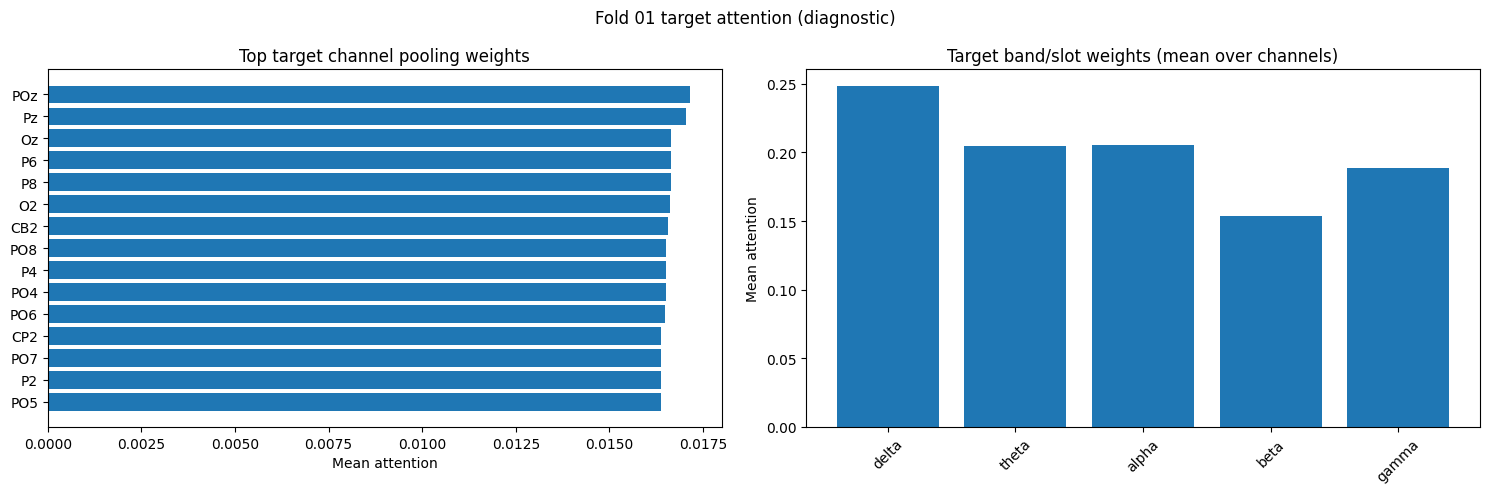

In [8]:
attention_fold = RUN_DIR / f'fold-{TARGET_SUBJECTS[-1]:02d}'
channel_path = attention_fold / 'target_channel_attention.csv'
band_path = attention_fold / 'target_band_attention.csv'
if not channel_path.is_file() or not band_path.is_file():
    print('Attention summaries are missing. Run the training cells with SAVE_TARGET_ATTENTION=True.')
else:
    channel_attention = pd.read_csv(channel_path)
    band_attention = pd.read_csv(band_path)
    band_global = (
        band_attention.groupby(['slot_index', 'slot'], as_index=False)['mean_attention']
        .mean()
        .sort_values('slot_index')
    )
    display(channel_attention.head(15).style.format({'mean_attention': '{:.4f}'}))
    display(band_global.style.format({'mean_attention': '{:.4f}'}))

    try:
        import matplotlib.pyplot as plt

        figure, axes = plt.subplots(1, 2, figsize=(15, 5))
        top_channels = channel_attention.head(15).sort_values('mean_attention')
        axes[0].barh(top_channels['channel'], top_channels['mean_attention'])
        axes[0].set(title='Top target channel pooling weights', xlabel='Mean attention')
        axes[1].bar(band_global['slot'], band_global['mean_attention'])
        axes[1].set(title='Target band/slot weights (mean over channels)', ylabel='Mean attention')
        axes[1].tick_params(axis='x', rotation=45)
        figure.suptitle(f'Fold {TARGET_SUBJECTS[-1]:02d} target attention (diagnostic)')
        figure.tight_layout()
        figure.savefig(attention_fold / 'target_attention_summary.png', dpi=160)
        plt.show()
    except ModuleNotFoundError:
        print('matplotlib is unavailable; attention CSV files were still saved')


## Interpretation

- The experiment changes only the model; preprocessing, source-only statistics, trials, and folds match the flat baseline.
- Compare source and target curves against `seediv_feature_tuning_monitor.ipynb` using the same feature, seed, subjects, and epoch count.
- Near-uniform attention is not automatically failure, but persistent uniformity plus weak accuracy suggests the gates are not specializing.
- Attention weights show learned pooling behavior, not causal electrode/band importance.
- Every target metric and target attention map here is peeked. Use source validation or pre-fixed choices for a formal result.
